# PixelRAG — Quickstart

Visual Retrieval-Augmented Generation: render documents as **screenshots**, search them as **images**. This notebook shows both, with the actual pictures.

```bash
pip install pixelrag
```

## 1. Render any page to screenshot tiles

The `pixelshot` command turns a URL into tiled JPEG screenshots — the visual form PixelRAG indexes and reads. (First run downloads a headless Chrome.)

2026-06-01 07:01:12,693 INFO pixelrag_render.render: Rendering 1 URL(s) with backend=cdp workers=4


demo_tiles/en.wikipedia.org_wiki_Terracotta_Army.png.tiles
rendered → demo_tiles/en.wikipedia.org_wiki_Terracotta_Army.png.tiles/tile_0000.jpg


2026-06-01 07:01:16,946 INFO pixelrag_render.backends.websocket: [w0] https://en.wikipedia.org/wiki/Terracotta_Army → 1 tiles (1.2s)
2026-06-01 07:01:16,979 INFO pixelrag_render.backends.websocket: Batch complete: done=1 failed=0
2026-06-01 07:01:16,980 INFO pixelrag_render.render: Done. 1 output(s):


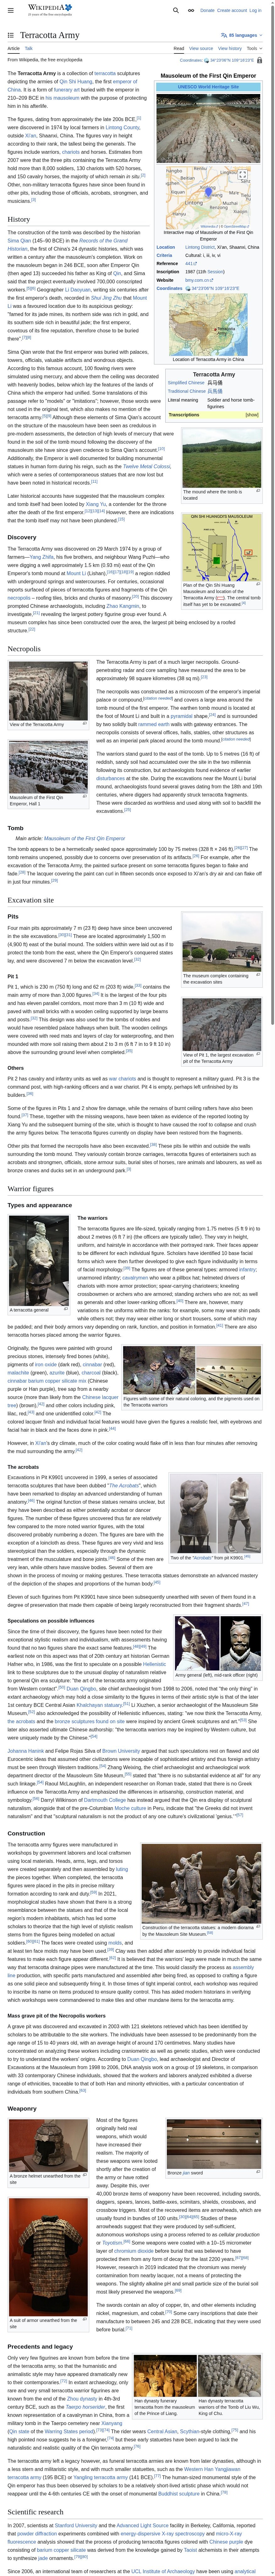

In [1]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

subprocess.run(
    [
        "pixelshot",
        "https://en.wikipedia.org/wiki/Terracotta_Army",
        "--output",
        "./demo_tiles",
    ],
    check=True,
)
first_tile = sorted(Path("./demo_tiles").glob("*/tile_*.jpg"))[0]
print("rendered →", first_tile)
display(Image(filename=str(first_tile), width=520))

## 2. Search the hosted Wikipedia index

Query the live API (8.28M pages) — in any language. Each hit returns tile coordinates; fetch the tile to **see** the matching screenshot.

0.524  Terracotta_Army


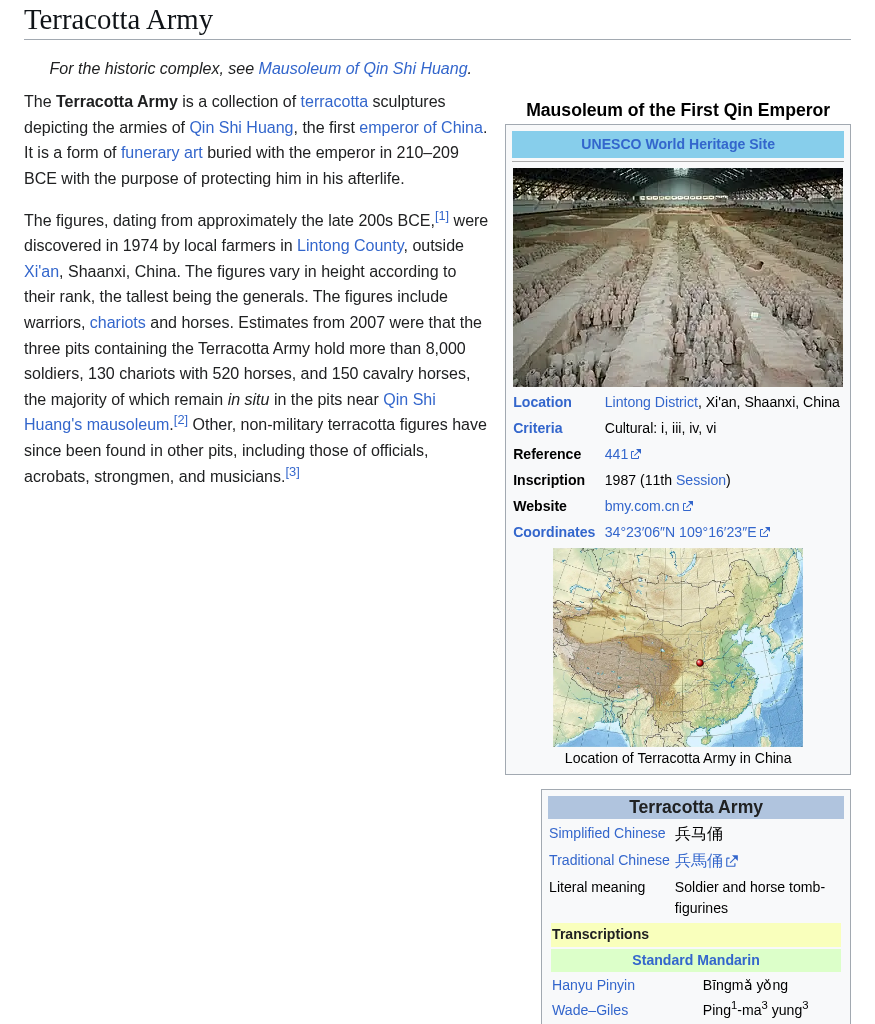

0.478  Taerpo_Horserider


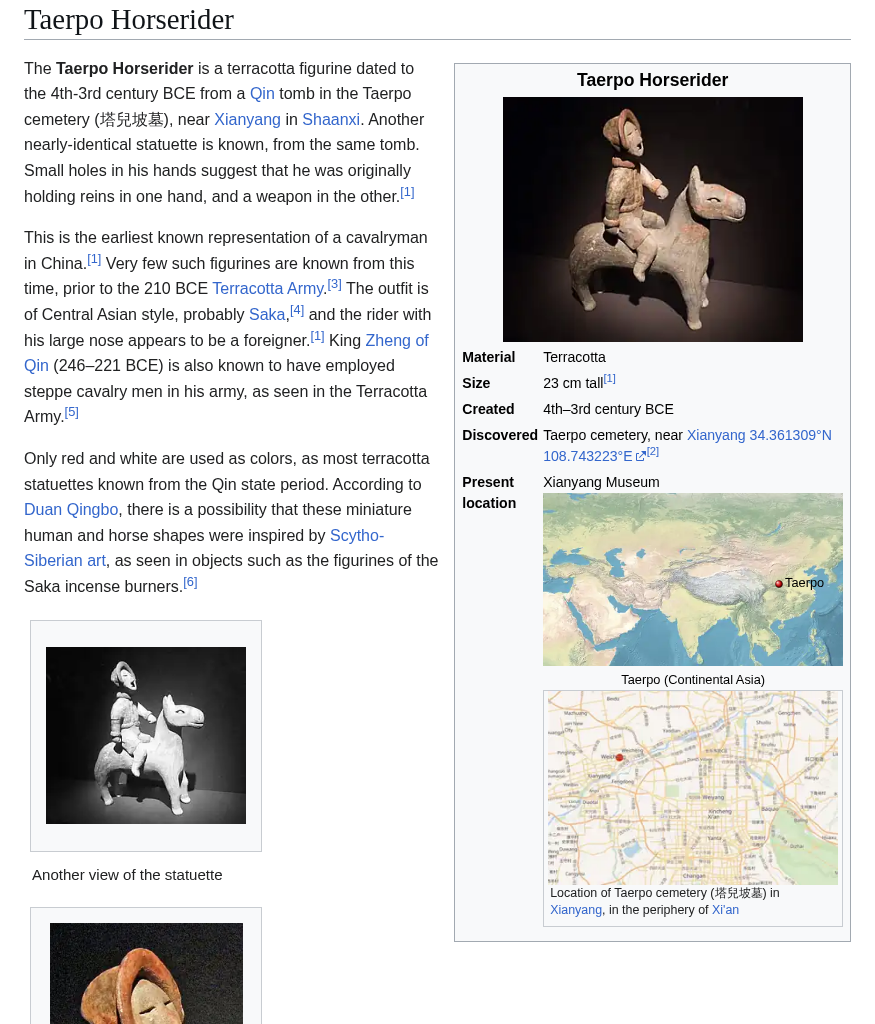

In [2]:
import requests
from IPython.display import Image, display

API = "https://api.pixelrag.ai"
hits = requests.post(
    f"{API}/search", json={"queries": [{"text": "兵马俑"}], "n_docs": 2}
).json()["results"][0]["hits"]

for h in hits:
    print(f"{h['score']:.3f}  {h['url']}")
    tile = f"{API}/tile/{h['article_id']}/{h['tile_index']}/{h['chunk_index']}"
    display(
        Image(data=requests.get(tile).content, width=420)
    )  # embed so it shows on GitHub